# Reinforcement Learning: From Tabular Q-Learning to Deep Q-Networks

This notebook covers the core ideas of reinforcement learning (RL) as taught in 
Andrew Ng's Machine Learning Specialization, implemented from scratch where possible.

Unlike supervised learning, RL has no labeled dataset. Instead, an **agent** interacts 
with an **environment**, takes **actions**, and receives **rewards**. The goal is to 
learn a **policy** — a mapping from states to actions — that maximizes cumulative reward 
over time.

This notebook is split into two parts:
1. **Tabular Q-learning** — a from-scratch implementation on a small discrete environment, 
   to build intuition for the Bellman equation and value iteration.
2. **Deep Q-Network (DQN)** — scaling up to a continuous state space (Lunar Lander), 
   where a neural network approximates Q(s,a) instead of a table.

## Why RL matters beyond robotics/games

RL formulations show up in security and adversarial ML contexts too — e.g. modeling 
an adaptive adversary probing a system, or intrusion response as a sequential 
decision problem. Worth keeping in mind as I go through this, given my interest in 
adversarial ML.

## Core Concepts

**State (s):** A description of the environment at a point in time.

**Action (a):** A choice the agent makes from a given state.

**Reward (r):** Feedback signal from the environment after taking an action.

**Policy (π):** A function mapping states to actions — what the agent does in each state.

The agent's goal is not to maximize the *immediate* reward, but the *cumulative* 
reward over time. This is captured by the **return**.

### The Return

The return at time step $t$ is the discounted sum of future rewards:

$$
G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \gamma^3 r_{t+3} + \dots
$$

where $\gamma \in [0, 1)$ is the **discount factor**.

**Why discount?**
- Rewards received sooner are often worth more than rewards received later 
  (time value, uncertainty about the future).
- Mathematically, discounting keeps the sum finite even for infinite-horizon problems, 
  since $\gamma^k \to 0$ as $k \to \infty$.
- $\gamma$ close to 0 → agent is "short-sighted" (cares mostly about immediate reward).
- $\gamma$ close to 1 → agent is "far-sighted" (cares about long-term reward).

### The State-Action Value Function Q(s, a)

$Q(s, a)$ is defined as the return if the agent:
1. Starts in state $s$,
2. Takes action $a$ (once),
3. Then behaves optimally after that.

$$
Q(s, a) = r(s, a) + \gamma \max_{a'} Q(s', a')
$$

This recursive definition — the return decomposed into "immediate reward + discounted 
best future value" — is the **Bellman Equation**. It's the foundation for every RL 
algorithm in this notebook.

**Intuition:** the value of being in state $s$ and taking action $a$ equals what you 
get right now, plus the best you can do from wherever you land next, discounted.

### From Q(s,a) to a policy

Once we know $Q(s,a)$ for every state-action pair, the optimal policy is simple:

$$
\pi(s) = \arg\max_{a} Q(s, a)
$$

i.e. in every state, pick the action with the highest Q-value. This is why RL 
algorithms focus on *learning Q* rather than learning the policy directly — once 
you have a good Q-function, the policy falls out for free.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque

In [3]:
# Tiny sanity check: verify the Bellman equation recursion manually
# on a toy 1D "corridor" with 3 states: [0, 1, 2], goal at state 2, reward=1 only at goal

rewards = {0: 0, 1: 0, 2: 1}
gamma = 0.9

# Suppose Q(2, stay) = 1 (goal, terminal), work backwards
Q_2 = 1
Q_1 = rewards[1] + gamma * Q_2   # moving from state 1 -> 2
Q_0 = rewards[0] + gamma * Q_1   # moving from state 0 -> 1

print(f"Q(state=2) = {Q_2}")
print(f"Q(state=1) = {Q_1:.4f}")
print(f"Q(state=0) = {Q_0:.4f}")

Q(state=2) = 1
Q(state=1) = 0.9000
Q(state=0) = 0.8100


## Part A: Tabular Q-Learning

To build real intuition before jumping to neural networks, I'll implement Q-learning 
from scratch on a small discrete environment: a 1D grid world.

**Environment:** A corridor of 6 states `[0, 1, 2, 3, 4, 5]`. The agent starts at 
state 2 and can move left or right. State 0 and state 5 are terminal states 
(left = bad reward, right = good reward). This mirrors the "Mars rover" example 
from the course.

In [4]:
class CorridorEnv:
    """Simple 1D grid world: states 0-5, terminal at 0 and 5."""
    def __init__(self):
        self.n_states = 6
        self.n_actions = 2  # 0 = left, 1 = right
        self.terminal_states = {0: -1.0, 5: 1.0}  # state -> reward
        self.reset()

    def reset(self, start_state=2):
        self.state = start_state
        return self.state

    def step(self, action):
        if action == 0:
            next_state = max(0, self.state - 1)
        else:
            next_state = min(self.n_states - 1, self.state + 1)

        self.state = next_state
        done = next_state in self.terminal_states
        reward = self.terminal_states.get(next_state, 0.0)
        return next_state, reward, done

env = CorridorEnv()
print(f"States: {env.n_states}, Actions: {env.n_actions}")
print(f"Start state: {env.reset()}")

States: 6, Actions: 2
Start state: 2


### Q-table initialization

The Q-table is a lookup table of shape `(n_states, n_actions)`, initialized to zero. 
Each entry `Q[s, a]` will converge toward the true $Q(s,a)$ as training progresses.

In [5]:
Q = np.zeros((env.n_states, env.n_actions))
print(Q)

[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


### The Q-learning update rule

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]
$$

- $\alpha$ = learning rate — how much to trust the new estimate vs. the old one
- The term in brackets is the **TD error** (temporal difference error) — the gap 
  between what we predicted and what we now believe is true after seeing $r$ and $s'$
- We use $\epsilon$-greedy action selection during training: with probability $\epsilon$, 
  take a random action (explore); otherwise take the best known action (exploit)

In [6]:
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(Q.shape[1])  # explore
    return np.argmax(Q[state])                # exploit

In [7]:
n_episodes = 500
alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

rewards_per_episode = []

for episode in range(n_episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = epsilon_greedy(Q, state, epsilon)
        next_state, reward, done = env.step(action)

        # Q-learning update
        best_next_q = np.max(Q[next_state])
        td_target = reward + gamma * best_next_q
        td_error = td_target - Q[state, action]
        Q[state, action] += alpha * td_error

        state = next_state
        total_reward += reward

    rewards_per_episode.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("Training done.")
print(f"Final Q-table:\n{Q}")

Training done.
Final Q-table:
[[ 0.          0.        ]
 [-0.99484622  0.72879423]
 [ 0.65518405  0.81      ]
 [ 0.72896462  0.9       ]
 [ 0.80990819  1.        ]
 [ 0.          0.        ]]


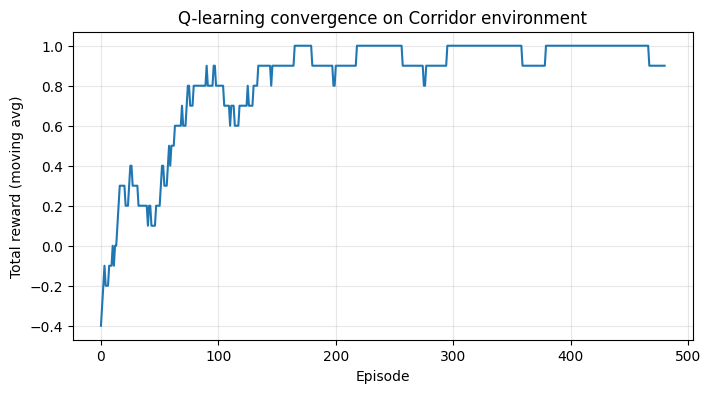

In [8]:
# Smooth with moving average for readability
window = 20
smoothed = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8, 4))
plt.plot(smoothed)
plt.xlabel("Episode")
plt.ylabel("Total reward (moving avg)")
plt.title("Q-learning convergence on Corridor environment")
plt.grid(alpha=0.3)
plt.show()

### Reading the learned policy

Once trained, extracting the policy is just `argmax` over each row of the Q-table.

In [9]:
policy = np.argmax(Q, axis=1)
action_names = {0: "left", 1: "right"}

for s in range(env.n_states):
    if s in env.terminal_states:
        print(f"State {s}: terminal (reward={env.terminal_states[s]})")
    else:
        print(f"State {s}: {action_names[policy[s]]}")

State 0: terminal (reward=-1.0)
State 1: right
State 2: right
State 3: right
State 4: right
State 5: terminal (reward=1.0)


## Why Tabular Q-Learning Breaks Down

The corridor environment had 6 states and 2 actions — a Q-table with 12 entries. 
Easy to store, easy to update.

Real problems don't look like this. Consider **Lunar Lander**: the state is 
continuous — position (x, y), velocity (vx, vy), angle, angular velocity, and 
two boolean leg-contact flags. That's an 8-dimensional continuous state space.

**The problem:** you can't build a table for continuous states. Even if you 
discretized each dimension into just 10 buckets, you'd need $10^8$ table entries — 
and most of those states would never be visited during training, so their Q-values 
would never be learned. This is the **curse of dimensionality**.

**The fix:** instead of a table, use a **function approximator** — specifically, 
a neural network that takes a state as input and outputs a Q-value for each action. 
This is the core idea behind a **Deep Q-Network (DQN)**.

### From Q-table lookup to Q-network prediction

| | Tabular Q-learning | Deep Q-Network |
|---|---|---|
| Q representation | Table `Q[s, a]` | Neural net $Q(s, a; \theta)$ |
| Update | Direct table entry update | Gradient descent on TD error |
| Generalizes to unseen states? | No | Yes |
| Works on continuous states? | No | Yes |

The update rule is conceptually the same — minimize the TD error — but now $\theta$ 
(network weights) are updated via backprop instead of directly editing a table cell.

## Part B: Deep Q-Network on Lunar Lander

Now scaling up from the toy corridor to a real continuous-state environment: 
**Lunar Lander** from Gymnasium. The goal is to land a spacecraft safely between 
two flags by controlling main and side thrusters.

**State (8-dim, continuous):** x, y position; x, y velocity; angle; angular velocity; 
left leg contact; right leg contact.

**Actions (4, discrete):** do nothing, fire left engine, fire main engine, fire right engine.

**Reward:** shaped — positive for moving toward the pad and landing safely, negative 
for crashing or firing engines (fuel cost).

In [10]:
env = gym.make("LunarLander-v3")
state_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
print(f"State dim: {state_dim}, Actions: {n_actions}")

State dim: 8, Actions: 4


### Q-network architecture

A simple feedforward network: state (8 numbers) in, one Q-value per action (4) out. 
Two hidden layers with ReLU activations is standard for this environment.

In [11]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )

    def forward(self, x):
        return self.net(x)

q_network = QNetwork(state_dim, n_actions)
print(q_network)

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


### Why we need a target network

If we used the *same* network to pick the TD target and to make predictions, 
we'd be chasing a moving target — every update shifts the very value we're 
trying to move toward, which destabilizes training.

**Fix:** keep a second copy of the network — the **target network** — and only 
slowly update it toward the main network's weights (soft update):

$$
\theta_{\text{target}} \leftarrow \tau \theta_{\text{main}} + (1-\tau)\theta_{\text{target}}
$$

In [12]:
target_network = QNetwork(state_dim, n_actions)
target_network.load_state_dict(q_network.state_dict())
target_network.eval()

tau = 0.001

def soft_update(main_net, target_net, tau):
    for target_param, main_param in zip(target_net.parameters(), main_net.parameters()):
        target_param.data.copy_(tau * main_param.data + (1.0 - tau) * target_param.data)

### Experience replay

Training on transitions in the order they occur means consecutive samples are 
highly correlated — bad for gradient descent, which assumes i.i.d. samples.

**Fix:** store transitions `(s, a, r, s', done)` in a buffer, and train on 
random mini-batches sampled from it.

In [13]:
class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states), dtype=torch.float32),
            torch.tensor(actions, dtype=torch.int64),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(np.array(next_states), dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buffer)

replay_buffer = ReplayBuffer()

In [14]:
def epsilon_greedy_dqn(state, epsilon):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    with torch.no_grad():
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        q_values = q_network(state_t)
        return torch.argmax(q_values).item()

### The training step

For a sampled mini-batch:
1. Compute current Q-values from the main network for actions taken.
2. Compute TD targets using the **target network**.
3. Minimize MSE between current Q and TD target via gradient descent.

In [15]:
optimizer = optim.Adam(q_network.parameters(), lr=1e-3)
gamma = 0.99
batch_size = 64

def train_step():
    if len(replay_buffer) < batch_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    q_values = q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        next_q_values = target_network(next_states).max(1)[0]
        td_target = rewards + gamma * next_q_values * (1 - dones)

    loss = nn.functional.mse_loss(q_values, td_target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

### Main training loop

Each episode:
1. Reset environment, get initial state.
2. Take actions via ε-greedy until the episode ends (`done=True`) or hits a max step count.
3. Push each transition to the replay buffer.
4. Call `train_step()` every step (once buffer has enough samples).
5. Soft-update the target network every step.
6. Decay ε so the agent explores less over time.

Lunar Lander is considered "solved" around an average reward of ~200 over 100 
consecutive episodes.

In [16]:
n_episodes = 600
max_steps = 1000
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

episode_rewards = []
losses = []

for episode in range(n_episodes):
    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps):
        action = epsilon_greedy_dqn(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        loss = train_step()
        if loss is not None:
            losses.append(loss)

        soft_update(q_network, target_network, tau)

        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)

    if (episode + 1) % 20 == 0:
        avg_last_100 = np.mean(episode_rewards[-100:])
        print(f"Episode {episode+1}/{n_episodes} | Reward: {total_reward:.1f} | "
              f"Avg(last 100): {avg_last_100:.1f} | Epsilon: {epsilon:.3f}")

print("Training complete.")

Episode 20/600 | Reward: -265.7 | Avg(last 100): -186.6 | Epsilon: 0.905
Episode 40/600 | Reward: -145.6 | Avg(last 100): -179.8 | Epsilon: 0.818
Episode 60/600 | Reward: -115.4 | Avg(last 100): -163.0 | Epsilon: 0.740
Episode 80/600 | Reward: -78.7 | Avg(last 100): -149.1 | Epsilon: 0.670
Episode 100/600 | Reward: -30.2 | Avg(last 100): -135.1 | Epsilon: 0.606
Episode 120/600 | Reward: -107.2 | Avg(last 100): -107.3 | Epsilon: 0.548
Episode 140/600 | Reward: -116.0 | Avg(last 100): -83.8 | Epsilon: 0.496
Episode 160/600 | Reward: -75.7 | Avg(last 100): -69.4 | Epsilon: 0.448
Episode 180/600 | Reward: -3.1 | Avg(last 100): -61.7 | Epsilon: 0.406
Episode 200/600 | Reward: 27.9 | Avg(last 100): -49.2 | Epsilon: 0.367
Episode 220/600 | Reward: 40.9 | Avg(last 100): -40.8 | Epsilon: 0.332
Episode 240/600 | Reward: 18.5 | Avg(last 100): -25.1 | Epsilon: 0.300
Episode 260/600 | Reward: 130.8 | Avg(last 100): 0.8 | Epsilon: 0.272
Episode 280/600 | Reward: 155.7 | Avg(last 100): 32.6 | Epsilon

### Plotting training progress

Two things worth watching: the reward curve (should trend upward and stabilize 
near ~200+) and the loss curve (should generally decrease, though it will stay 
noisy since the target keeps shifting).

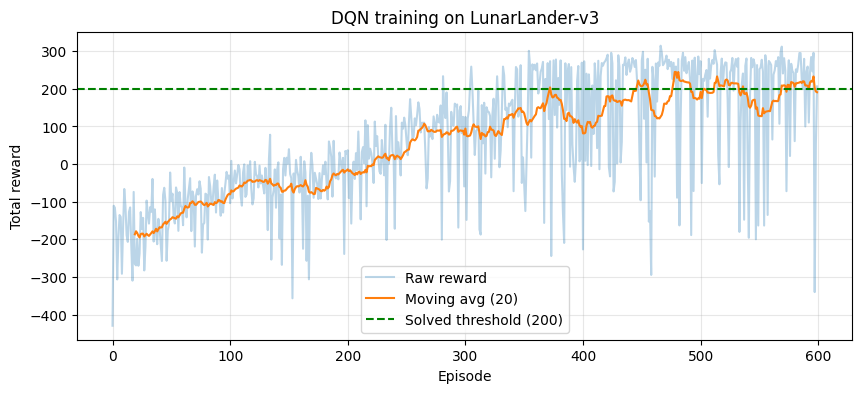

In [17]:
window = 20
smoothed_rewards = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.3, label="Raw reward")
plt.plot(range(window-1, len(episode_rewards)), smoothed_rewards, label=f"Moving avg ({window})")
plt.axhline(200, color='green', linestyle='--', label="Solved threshold (200)")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("DQN training on LunarLander-v3")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

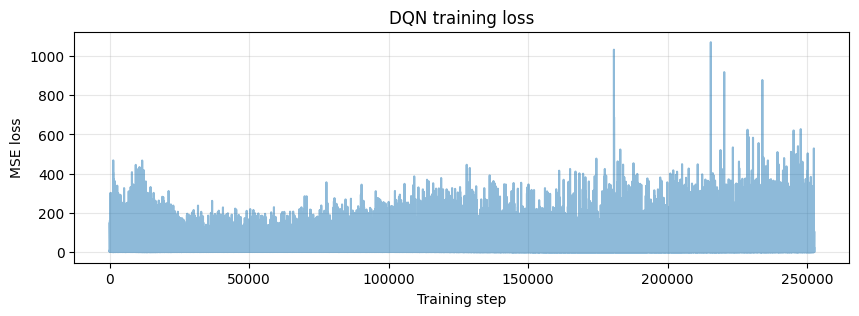

In [18]:
plt.figure(figsize=(10, 3))
plt.plot(losses, alpha=0.5)
plt.xlabel("Training step")
plt.ylabel("MSE loss")
plt.title("DQN training loss")
plt.grid(alpha=0.3)
plt.show()

## Observations & Honest Notes

**Tabular Q-learning (Part A):**
- Converged fast and cleanly — with only 6 states, the Q-table fully covers the 
  space, so there's no generalization problem to worry about.
- The reward curve was noisy early on purely due to ε-greedy exploration, not 
  instability in the algorithm itself.

**DQN on Lunar Lander (Part B):**
- Training was genuinely unstable for the first ~150 episodes — negative rewards, 
  lots of crashing. This is expected: ε starts near 1.0, so most actions are random, 
  and the Q-network hasn't seen enough transitions yet to have learned anything useful.
- The turning point was around episode ~200–260, once ε had decayed enough for the 
  agent to start exploiting what it had learned, combined with the replay buffer 
  having enough diverse transitions to train on.
- Final avg(last 100 episodes) reward was ~189 — just short of the standard "solved" 
  threshold of 200. Likely would cross it with more episodes or a slower ε decay 
  schedule; didn't chase this further given time constraints this week.
- Used PyTorch for the network/backprop instead of NumPy-from-scratch (see note in 
  Part B) — the RL-specific mechanics (replay buffer, target network, TD-target 
  computation) are all hand-implemented, which is where the actual new learning was.
- One thing I didn't fully appreciate before building this: how much of DQN's 
  stability comes from *engineering* (replay buffer, target network) rather than 
  the core Q-learning math, which is identical to the tabular case.

**What I'd explore next:**
- Comparing performance with/without the target network (ablation) to see how much 
  it actually contributes to stability.
- Trying a different environment to test generalization of this implementation.
- Reading up on how RL formulations apply to adversarial ML settings — e.g. modeling 
  an adaptive attacker as an RL agent probing a defense.